**Table of contents**<a id='toc0_'></a>    
- [Introduction](#toc1_)    
- [Methodology - SSALAD](#toc2_)    
  - [Querying Techniques](#toc2_1_)    
    - [Random querying](#toc2_1_1_)    
    - [Uncertainty querying](#toc2_1_2_)    
    - [Anomalous querying](#toc2_1_3_)    
    - [Medoid querying](#toc2_1_4_)    
  - [Label Propagation](#toc2_2_)    
  - [Model Training](#toc2_3_)    
  - [Continuous Active Learning](#toc2_4_)    
- [Experiment Results](#toc3_)    
  - [Semi Supervised Model (Using Label Propagation) vs. Unsupervised Model](#toc3_1_)    
  - [A Comparison of Different Querying Techniques](#toc3_2_)    
  - [Increase in Average ROC_AUC as More Data is Labelled](#toc3_3_)    
- [References](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Introduction](#toc0_)

Unsupervised models excel at identifying statistical outliers within a dataset. This works well as these models are sensitive to instances which deviate from the global norm. For anomaly detection this might not be enough. In domain-specific scenarios, anomalies within a dataset might be self-similar and could even exist within well-populated local neighborhoods. Consequently, an unsupervised model might overlook these instances in favor of those which stand-out. For example, a model might flag a single 100 million USD transaction if the dataset average is 25 million USD per transaction. Picking such an instance as an anomaly is easy but useless to a forensic accountant who might be more interested in a dozen 5 million USD transactions done by six different accounts within minutes of each other.

Due to the inflexibility of these models, semi-supervised models have become the norm in anomaly detection. Semi-supervised models combine the strengths of supervised and unsupervised learning. Supervised learning models tend to be highly accurate and effective due to the presence of labels during training. The performance of these models is also easier to measure as true labels can be compared to predicted labels. Unsupervised learning eliminates the need for labels while still producing robust models. This is great for anomaly detection as these models can identify inherent patterns within a dataset e.g., by creating clusters or by using tree-based tactics which can pick out anomalous instances. However, as noted before, these unsupervised models don't always do well when faced with domain-specific anomalies.

Semi-supervised models, unlike supervised models which demand an entire dataset be labelled, can improve performance even when trained on very few labels. Moreover, unlike unsupervised models whose predicted labels/clusters might not reflect the real-world, these models can identify domain-specific anomalies because they have labels to reference (regardless of how few these might). While labels might be expensive to acquire, the improved performance of these models on anomaly detection tasks has fueled their popularity.

This popularity is partly due to label propagation, a cornerstone semi-supervised algorithm, which has made it possible to train highly accurate models on sparsely-labelled datasets. Label propagation diffuses a few labels to all unlabeled instances within the dataset. This can be achieved due to the assumption that an instance label is also the label of the community/neighborhood that the instance belongs to. Therefore, if an instance is labeled as fraudulent its closest neighbors should also be fraudulent. In an iterative process, label propagation can start with a 5% labeled dataset and generate pseudo-labels fro the rest of the dataset.

While label propagation might be effective, its performance is dependent on the accuracy and timeliness of the existing labels. The temptation to use labeled legacy data is high especially for organizations that want to achieve quick results. However, this leads to models that are outdated on launch. This is where active learning comes in. Active learning queries users for instance labels on a regular basis. This ensures that the labels are timely and that the models can evolve even when the definition of what is anomalous within a domain changes.

In this paper we propose an approach, called Semi-supervised Active Learning Anomaly Detection (SSALAD), which implements a variety of querying techniques to acquire labels from users in order to build a robust anomaly detection model. By taking advantage of active learning, SSALAD ensures that the model will still perform well even when domain-specific anomalies evolve.

# <a id='toc2_'></a>[Methodology - SSALAD](#toc0_)

## <a id='toc2_1_'></a>[Querying Techniques](#toc0_)

There are four querying techniques which SSALAD implements: random, uncertainty, anomalous, and medoid querying. The use of the SSAD model gets to choose one of them during the model training process.

### <a id='toc2_1_1_'></a>[Random querying](#toc0_)

Random querying uses simple random sampling (SRS) to present users with instances to label. Its main advantage is that it's unbiased and any instance within the dataset can be presented for labeling. This means that the user will help the model in identifying both inliers and outliers within the dataset.

<div>
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20231110115024/Simple-Random-Sampling.png" height="400"/>
</div>

### <a id='toc2_1_2_'></a>[Uncertainty querying](#toc0_)

This querying technique presents the most uncertain instances for the user to label. The uncertainty is based on the prediction confidence of the SSALAD model. The lower the confidence the more likely we will present the instance to the user for labelling.

<div>
<img src="https://analystprep.com/cfa-level-1-exam/wp-content/uploads/2019/10/page-159.jpg" height="400"/>
</div>

### <a id='toc2_1_3_'></a>[Anomalous querying](#toc0_)

The SSALAD model generates anomaly scores for each instance. The bigger the score the more anomalous the instance. In this case, we have a choice of presenting the user with the instances that have the highest or lowest anomaly scores.

<div>
<img src="https://dataheroes.ai/wp-content/uploads/2023/05/post-2457-1.png"/>
</div>

### <a id='toc2_1_4_'></a>[Medoid querying](#toc0_)

Medoid querying uses clustering to determine the medoid of each neighborhood/community. The medoid is the most representative instance within that community. Presenting the user with a medoid, allows us to get a label that accurately describes the entirety of its neighborhood.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/8/81/CarMedoidExample.png" height="300"/>
</div>

## <a id='toc2_2_'></a>[Label Propagation](#toc0_)

Querying labels for 100% of the instances within a dataset is quite expensive. This is why once a few labels have been queried we carry out label propagation. Using label propagation we diffuse the collected labels to the rest of the dataset. The result will be a dataset whose instances are identified to be either outliers or inliers.

<div>
<img src="https://dist.neo4j.com/wp-content/uploads/20190226091707/label-propagation-graph-algorithm-1.png"/>
</div>

## <a id='toc2_3_'></a>[Model Training](#toc0_)

A unique feature of SSALAD is how the model is trained. Instead of using the labelled dataset, created through label propagation, to train a supervised classified, we train the mode only on inliers. This is achieved by dropping all outlier instances from the labeled dataset. The resultant model will be quite sensitive to outliers and will generally outperform models which were trained with the full dataset.

## <a id='toc2_4_'></a>[Continuous Active Learning](#toc0_)

The model training described above greatly improves when coupled with active learning. When users are constantly queried for labels, the SSALAD model can pick up on changes in the distribution of the data. Therefore, if the inliers or outliers change neighborhoods, or if new neighborhoods are created, the model will still be able to detect anomalous instances.

<div>
<img src="https://www.cloudfactory.com/hs-fs/hubfs/04-blog-img/Scalable-Active-Learning-for-Autonomous-Driving.png?width=2130&name=Scalable-Active-Learning-for-Autonomous-Driving.png" height="400"/>
</div>

# <a id='toc3_'></a>[Experiment Results](#toc0_)

After the experiments have been run we end up with results that look like this:

In [ ]:
results = pd.read_csv('/content/drive/MyDrive/data/final_results_csv')
results.head()

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,roc_auc
0,33_skin,500,KNN,0.0,0,random,True,0.711563
1,33_skin,500,KNN,0.0,1,random,True,0.748595
2,33_skin,500,KNN,0.0,2,random,True,0.697515
3,33_skin,500,KNN,0.0,3,random,True,0.779258
4,33_skin,500,KNN,0.0,4,random,True,0.714736


With these results we can answer important questions about the performance of semi-supervised models and moreover, we can determine how much the performance improves if you were to select a specific querying strategy.

##Plotting Functions

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [109]:
def plot_propagation_comparison(results_df):
    """
    Creates Seaborn line plots comparing ROC AUC for propagation True vs. False,
    grouped by model and dataset, with 3 columns per row.

    Args:
        results_df: DataFrame containing the results.
    """

    # Get unique model and dataset names
    model_names = results_df['model'].unique()
    dataset_names = results_df['dataset'].unique()

    # Calculate number of rows needed for the grid
    num_rows = int(np.ceil(len(dataset_names) / 3))

    # Create subplots with 3 columns per row
    fig, axes = plt.subplots(num_rows, 3,
                             figsize=(18, 6 * num_rows), sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0.2, wspace=0.1)

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    for k, dataset_name in enumerate(dataset_names):
        ax = axes[k]  # Get the current subplot axis

        # Filter data for the current dataset
        dataset_data = results_df[results_df['dataset'] == dataset_name]

        # Create the line plot for both models in the same subplot
        sns.lineplot(data=dataset_data, x='fraction', y='roc_auc',
                     hue='propagation', errorbar='sd', style='model', ax=ax)

        ax.set_title(f'{dataset_name}')
        ax.set_xlabel('Fraction of Labeled Data')
        ax.set_ylabel('ROC AUC')
        ax.legend(title='Propagation & Model')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(dataset_names), len(axes)):
        axes[i].set_visible(False)

    plt.show()

In [108]:
def plot_query_strategy_comparison(results_df):
    """
    Creates Seaborn line plots comparing ROC AUC for different query strategies,
    grouped by dataset and model, with 3 columns per row.

    Args:
        results_df: DataFrame containing the results.
    """

    # Get unique model and dataset names
    model_names = results_df['model'].unique()
    dataset_names = results_df['dataset'].unique()

    sns.color_palette("Paired")

    # Calculate number of rows needed for the grid
    num_rows = int(np.ceil(len(dataset_names) / 3))

    # Create subplots with 3 columns per row
    fig, axes = plt.subplots(num_rows, 3,
                             figsize=(18, 6 * num_rows), sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0.2, wspace=0.1)

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    for k, dataset_name in enumerate(dataset_names):
        ax = axes[k]  # Get the current subplot axis

        # Filter data for the current dataset
        dataset_data = results_df[results_df['dataset'] == dataset_name]

        # Create the line plot for both models in the same subplot
        sns.lineplot(data=dataset_data, x='fraction', y='roc_auc',
                     hue='query_strategy', errorbar='sd', ax=ax)

        ax.set_title(f'{dataset_name}')
        ax.set_xlabel('Fraction of Labeled Data')
        ax.set_ylabel('ROC AUC')
        ax.legend(title='Query Strategy & Model')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(dataset_names), len(axes)):
        axes[i].set_visible(False)

    plt.show()

In [107]:
def plot_roc_auc_change_by_query_strategy(results_df):
    """
    Creates Seaborn line plots showing the average change in ROC AUC
    as the fraction of labeled data increases, grouped by dataset and
    query strategy, with 3 columns per row.

    Args:
        results_df: DataFrame containing the results.
    """

    # Get unique dataset and query strategy names
    dataset_names = results_df['dataset'].unique()
    query_strategies = results_df['query_strategy'].unique()

    # Calculate the number of rows needed for the grid
    num_rows = int(np.ceil(len(dataset_names) / 3))

    # Create subplots with 3 columns per row
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
    fig.subplots_adjust(hspace=0.2, wspace=0.3)  # Adjust spacing

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    subplot_index = 0  # Keep track of the current subplot

    for dataset_name in dataset_names:
        ax = axes[subplot_index]  # Get the current subplot axis

        # Filter data for the current dataset
        dataset_data = results_df[results_df['dataset'] == dataset_name]

        for query_strategy in query_strategies:
            # Filter data for the current query strategy
            strategy_data = dataset_data[dataset_data['query_strategy'] == query_strategy]

            # Calculate the average ROC AUC for each fraction
            avg_roc_auc = strategy_data.groupby('fraction')['roc_auc'].mean().reset_index()

            # Calculate the change in ROC AUC from the initial value
            initial_roc_auc = avg_roc_auc['roc_auc'].iloc[0]  # Get initial ROC AUC
            avg_roc_auc['roc_auc_change'] = avg_roc_auc['roc_auc'] - initial_roc_auc

            # Create the line plot for the current query strategy
            sns.lineplot(data=avg_roc_auc, x='fraction', y='roc_auc_change',
                         label=query_strategy, ax=ax)  # Add label for legend

        ax.set_title(f'{dataset_name}')
        ax.set_xlabel('Fraction of Labeled Data')
        ax.set_ylabel('Change in Avg. AUC')
        ax.legend(title='Query Strategy')  # Add legend
        ax.grid(True)

        subplot_index += 1  # Move to the next subplot

    # Hide any unused subplots
    for j in range(subplot_index, len(axes)):
        axes[j].set_visible(False)

    plt.show()

In [ ]:
def plot_roc_auc_change_by_propagation(results_df):
    """
    Creates Seaborn line plots showing the average change in ROC AUC
    as the fraction of labeled data increases, grouped by dataset and
    query strategy, with 3 columns per row.

    Args:
        results_df: DataFrame containing the results.
    """

    # Get unique dataset and query strategy names
    dataset_names = results_df['dataset'].unique()
    propagations = results_df['propagation'].unique()

    # Calculate the number of rows needed for the grid
    num_rows = int(np.ceil(len(dataset_names) / 3))

    # Create subplots with 3 columns per row
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
    fig.subplots_adjust(hspace=0.2, wspace=0.3)  # Adjust spacing

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    subplot_index = 0  # Keep track of the current subplot

    for dataset_name in dataset_names:
        ax = axes[subplot_index]  # Get the current subplot axis

        # Filter data for the current dataset
        dataset_data = results_df[results_df['dataset'] == dataset_name]

        for prop in propagations:
            # Filter data for the current
            strategy_data = dataset_data[dataset_data['propagation'] == prop]

            # Calculate the average ROC AUC for each fraction
            avg_roc_auc = strategy_data.groupby('fraction')['roc_auc'].mean().reset_index()

            # Calculate the change in ROC AUC from the initial value
            initial_roc_auc = avg_roc_auc['roc_auc'].iloc[0]  # Get initial ROC AUC
            avg_roc_auc['roc_auc_change'] = avg_roc_auc['roc_auc'] - initial_roc_auc

            # Create the line plot for the current query strategy
            sns.lineplot(data=avg_roc_auc, x='fraction', y='roc_auc_change',
                         label=prop, ax=ax)  # Add label for legend

        ax.set_title(f'{dataset_name}')
        ax.set_xlabel('Fraction of Labeled Data')
        ax.set_ylabel('Change in Avg. AUC')
        ax.legend(title='Propagation')  # Add legend
        ax.grid(True)

        subplot_index += 1  # Move to the next subplot

    # Hide any unused subplots
    for j in range(subplot_index, len(axes)):
        axes[j].set_visible(False)

    plt.show()

## <a id='toc3_1_'></a>[Semi Supervised Model (Using Label Propagation) vs. Unsupervised Model](#toc0_)

The first question is whether using a semi-supervised model with label propagation leads to a higher roc_auc.

The plots below compare two types of models: a semi-supervised model with label propagation and an unsupervised model without label propagation. Both of these model types were trained with inlier data i.e., outliers were removed prior to training.

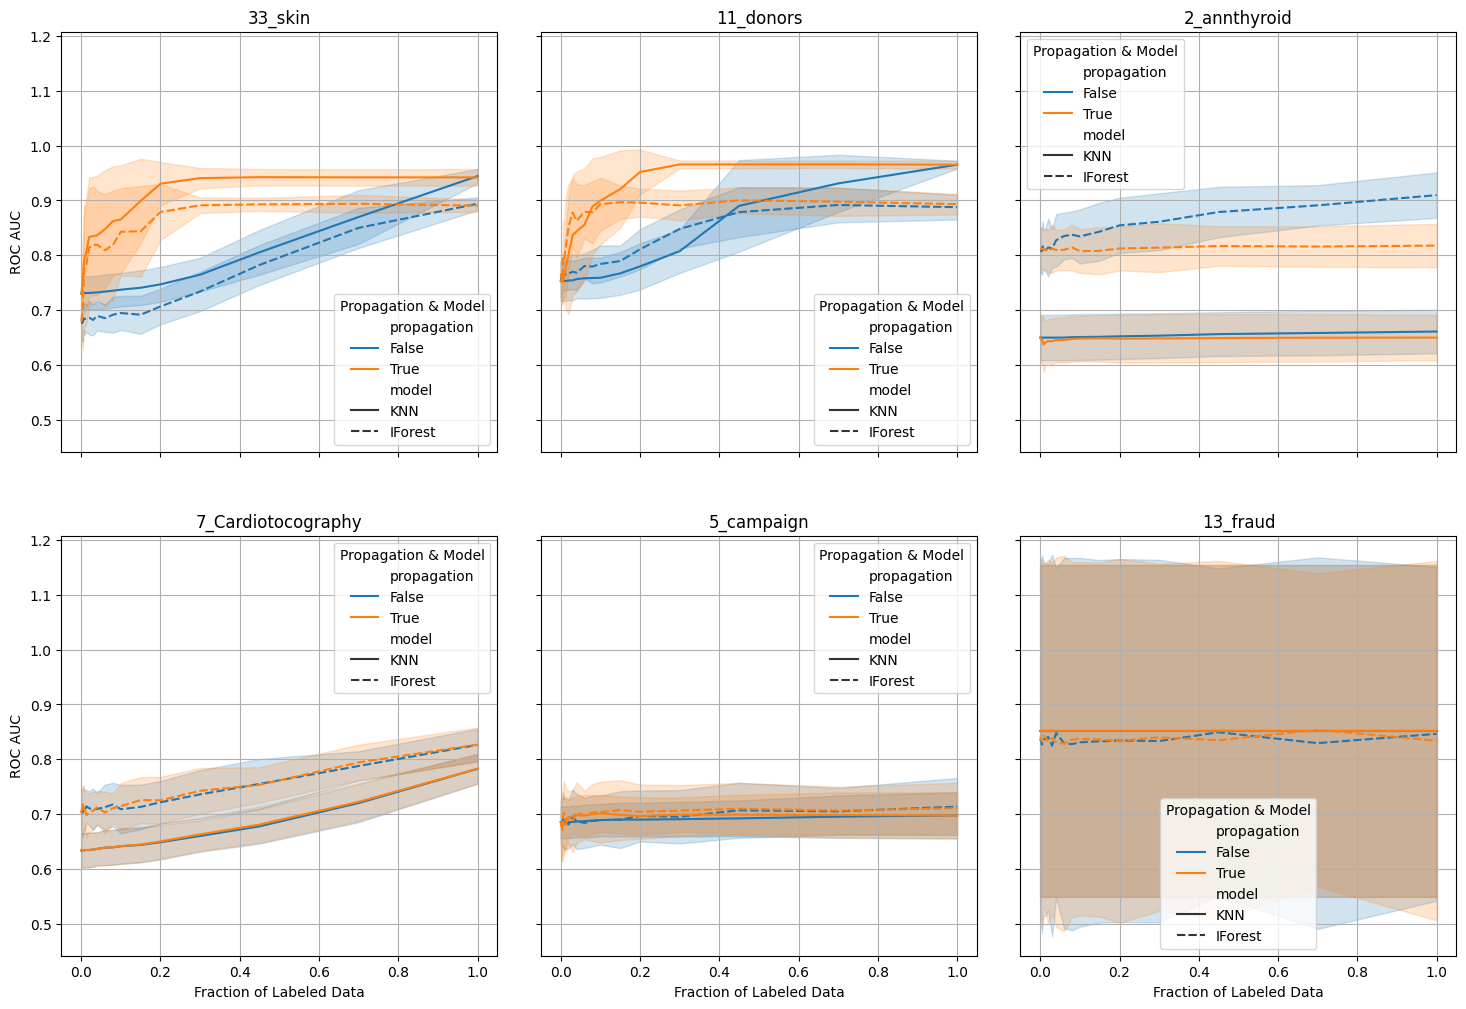

In [110]:
plot_propagation_comparison(results)

From the six plots shown above, some patterns become immediately apparent. First, whether a model performs well or not is dependent on the dataset.

Secondly, given enough number of labels both the unsupervised and semi-supervised models can converge on a good enough roc_auc. However, the reason we pick a semi-supervised model is to deal with the expenses related to labeling. Therefore, we need to focus on performance when the dataset has small fractions of labeled data.

In these scenarios, label propagation outperforms unsupervised anomaly detection. Even in the campaign dataset, which has all the different combinations performing quite similarly, we can see that the IForest and KNN label-propagated models are slightly better. In the skin and donors datasets, this performance boost is clearer.

To see this more clearly, the table below shows the best performing model for each dataset when we have fewer than 2% of labels available. Only the random querying strategy is considered here.

In [131]:
# Filter data for fractions less than 0.02
filtered_df = results[results['fraction'] < 0.02]
filtered_df = results[results['query_strategy'] == "random"]

# Group data, calculate average roc_auc, and sort
avg_roc_auc = filtered_df.groupby(['dataset', 'propagation', 'model'])['roc_auc'].mean()

# Find the best combination for each dataset
best_combinations = avg_roc_auc.loc[avg_roc_auc.groupby('dataset').idxmax()]

# Display the results
print(best_combinations)

dataset             propagation  model  
11_donors           True         KNN        0.867469
13_fraud            False        KNN        0.852000
2_annthyroid        False        IForest    0.825435
33_skin             True         KNN        0.899613
5_campaign          True         IForest    0.698816
7_Cardiotocography  False        IForest    0.727907
Name: roc_auc, dtype: float64


The table below shows the best model for each dataset if we have fewer or equal to 20% of labels available.

In [ ]:
# Filter data for fractions less than 0.2
filtered_df = results[results['fraction'] <= 0.2]
filtered_df = results[results['query_strategy'] == "random"]

# Group data, calculate average roc_auc, and sort
avg_roc_auc = filtered_df.groupby(['dataset', 'propagation', 'model'])['roc_auc'].mean()

# Find the best combination for each dataset
best_combinations = avg_roc_auc.loc[avg_roc_auc.groupby('dataset').idxmax()]

# Display the results
print(best_combinations)

dataset             propagation  model  
11_donors           True         KNN        0.867469
13_fraud            False        KNN        0.852000
2_annthyroid        False        IForest    0.825435
33_skin             True         KNN        0.899613
5_campaign          True         IForest    0.698816
7_Cardiotocography  False        IForest    0.727907
Name: roc_auc, dtype: float64


## <a id='toc3_2_'></a>[A Comparison of Different Querying Techniques](#toc0_)

Learning whether the semi-supervised or unsupervised models are better is a good start. For a specific dataset this will tell us whether the semi-supervised approach will be more beneficial than an unsupervised approach.

For domain-specific scenarios, we need a better comparison. This is where the comparison of the querying techniques comes up.

The plots below show how different querying techniques perform.

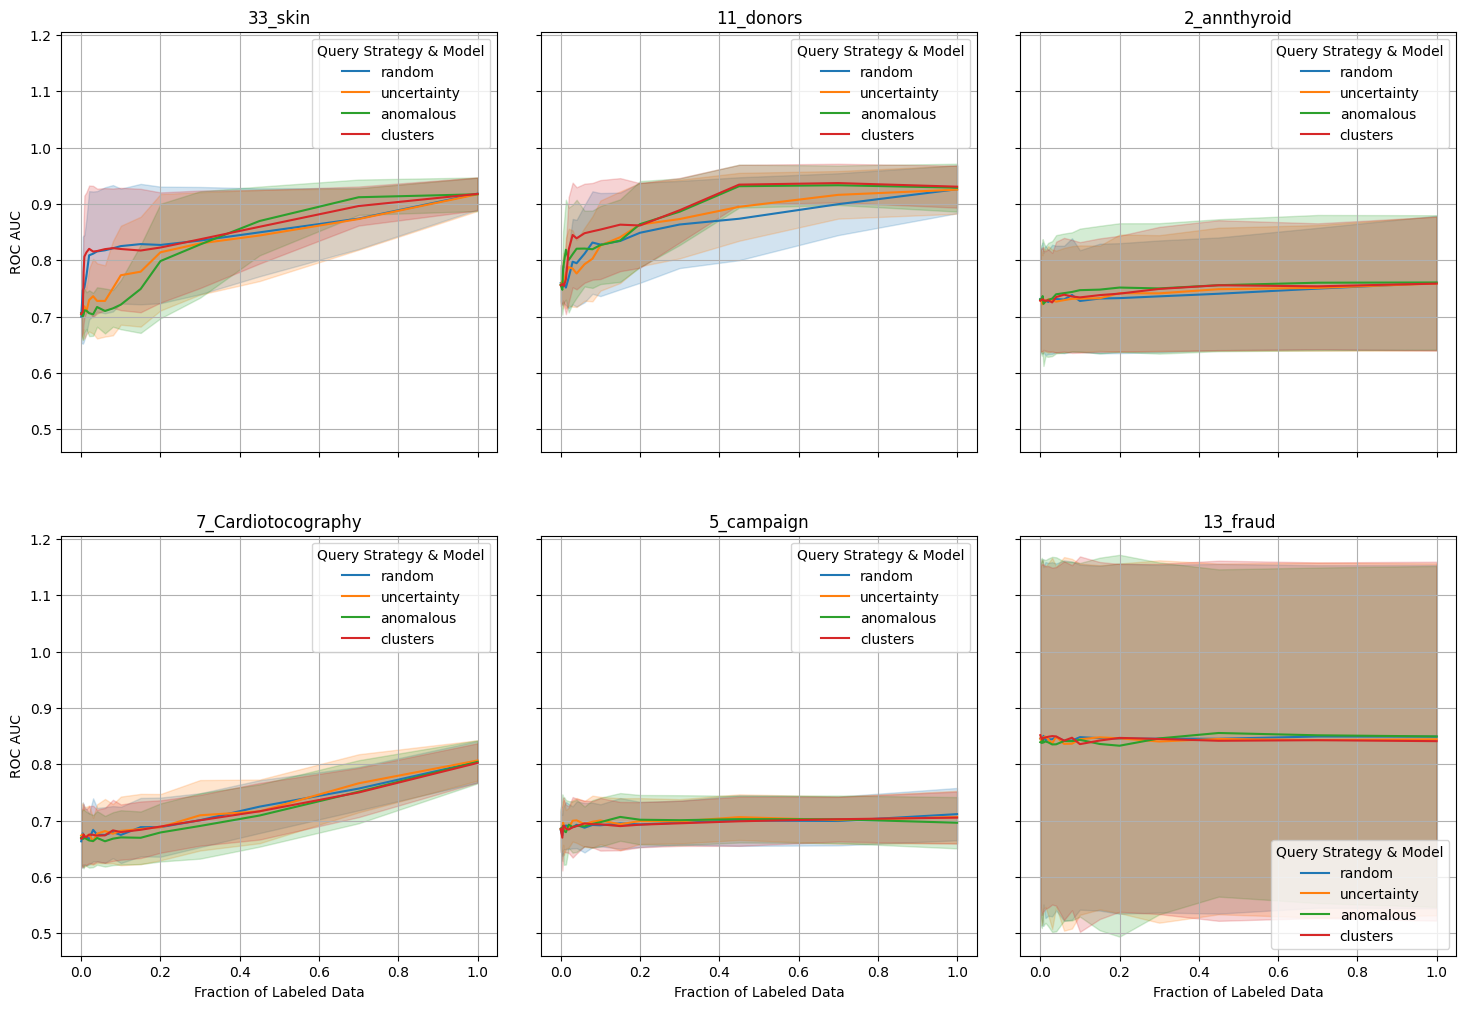

In [111]:
plot_query_strategy_comparison(results)

The table below shows a summary of the best querying technique for each dataset when we have 5% or fewer labels. Propagation is considered here.

In [128]:
# Filter data for fractions less than 0.05
filtered_df = results[results['fraction'] <= 0.05]

# Group data, calculate average roc_auc, and sort
avg_roc_auc = filtered_df.groupby(['dataset', 'query_strategy', 'model', 'propagation'])['roc_auc'].mean().sort_values(ascending=False)

# Find the best combination for each dataset
best_combinations = avg_roc_auc.loc[avg_roc_auc.groupby('dataset').idxmax()]

# Display the results
print(best_combinations)

dataset             query_strategy  model    propagation
11_donors           anomalous       IForest  True           0.867304
13_fraud            anomalous       KNN      False          0.852000
2_annthyroid        anomalous       IForest  False          0.827637
33_skin             clusters        KNN      True           0.872549
5_campaign          uncertainty     IForest  True           0.700569
7_Cardiotocography  random          IForest  False          0.711545
Name: roc_auc, dtype: float64


For the six datasets, when both query strategy and propagation are considered, anomalous querying comes up on top

What if we had more labels? The table provides the results if we assume 20% of each dataset is labelled.

In [127]:
# Filter data for fractions less than 0.2
filtered_df = results[results['fraction'] <= 0.2]

# Group data, calculate average roc_auc, and sort
avg_roc_auc = filtered_df.groupby(['dataset', 'query_strategy', 'model', 'propagation'])['roc_auc'].mean().sort_values(ascending=False)

# Find the best combination for each dataset
best_combinations = avg_roc_auc.loc[avg_roc_auc.groupby('dataset').idxmax()]

# Display the results
print(best_combinations)

dataset             query_strategy  model    propagation
11_donors           anomalous       IForest  True           0.883493
13_fraud            random          KNN      True           0.852000
2_annthyroid        anomalous       IForest  False          0.844827
33_skin             clusters        KNN      True           0.899722
5_campaign          uncertainty     IForest  True           0.703304
7_Cardiotocography  uncertainty     IForest  True           0.718110
Name: roc_auc, dtype: float64


Given more labels, anomalous and uncertainty querying strategies come out as the most frequent. Moreover, label propagation also comes out on top.

## <a id='toc3_3_'></a>[Increase in Average ROC_AUC as More Data is Labelled](#toc0_)

A recurring theme is that as we get more labels the performance changes. Of course, we have also determined that the more labels we add the more expensive our anomalous detection process will become. Therefore, we need to understand how much each percentage increase in label collection offers us in terms of performance.

The plot below shows how the increase in average roc_auc is influenced by an increase in % of labelled data. In this case we take whether there is label propagation or not.

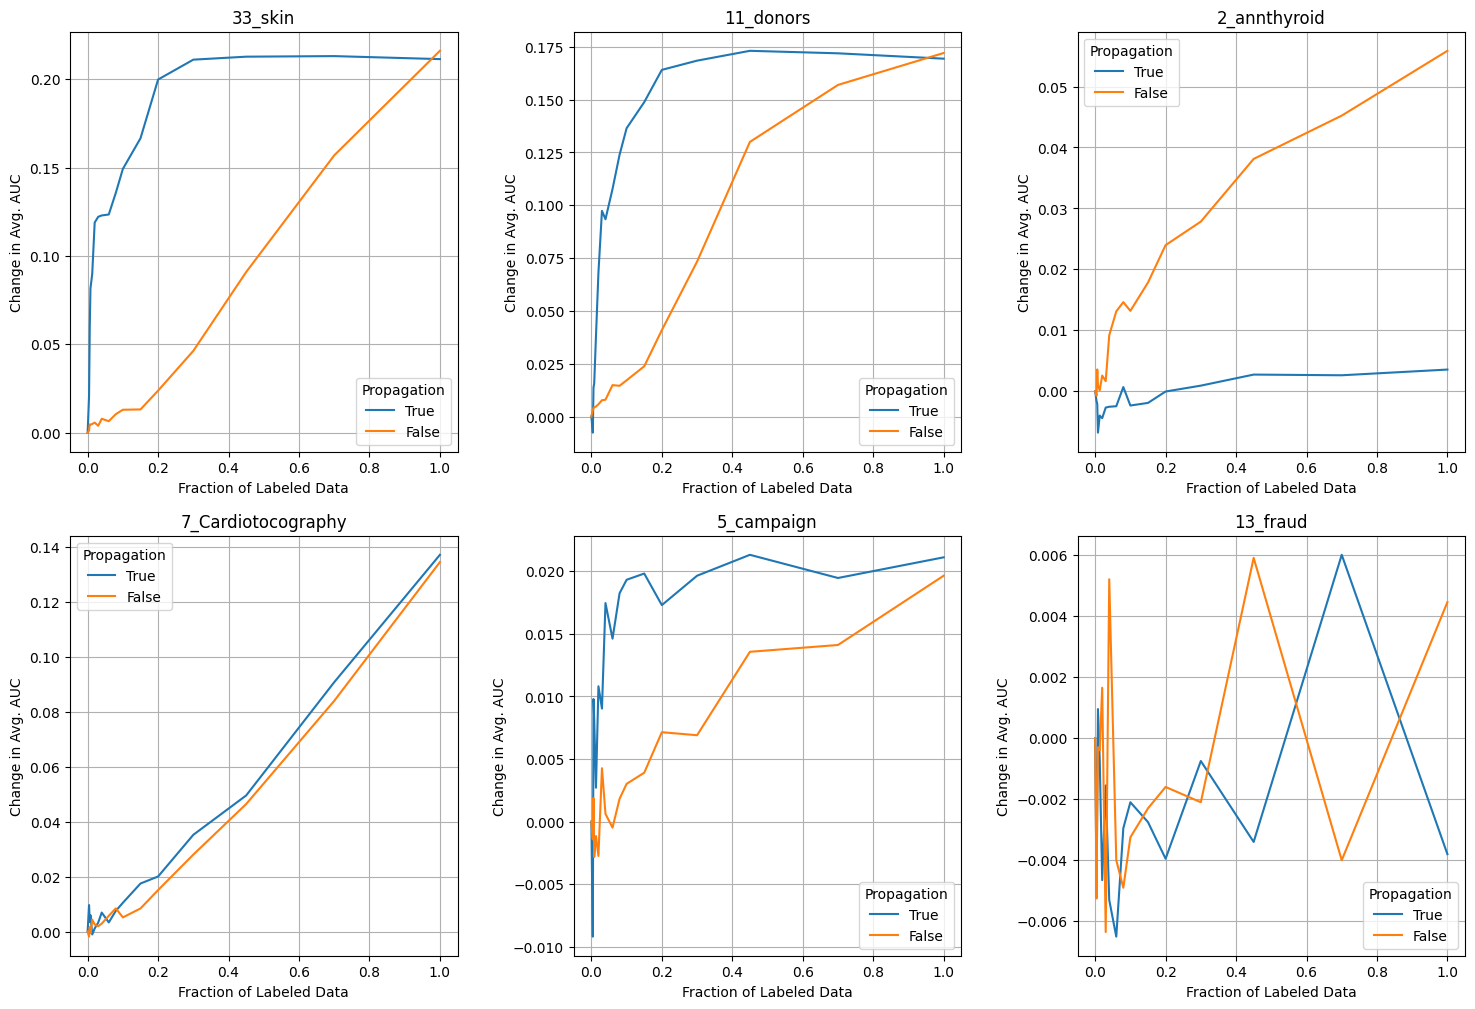

In [116]:
plot_roc_auc_change_by_propagation(results)

Now, we take into consideration how much the jump in average roc_auc is influenced by query strategy:

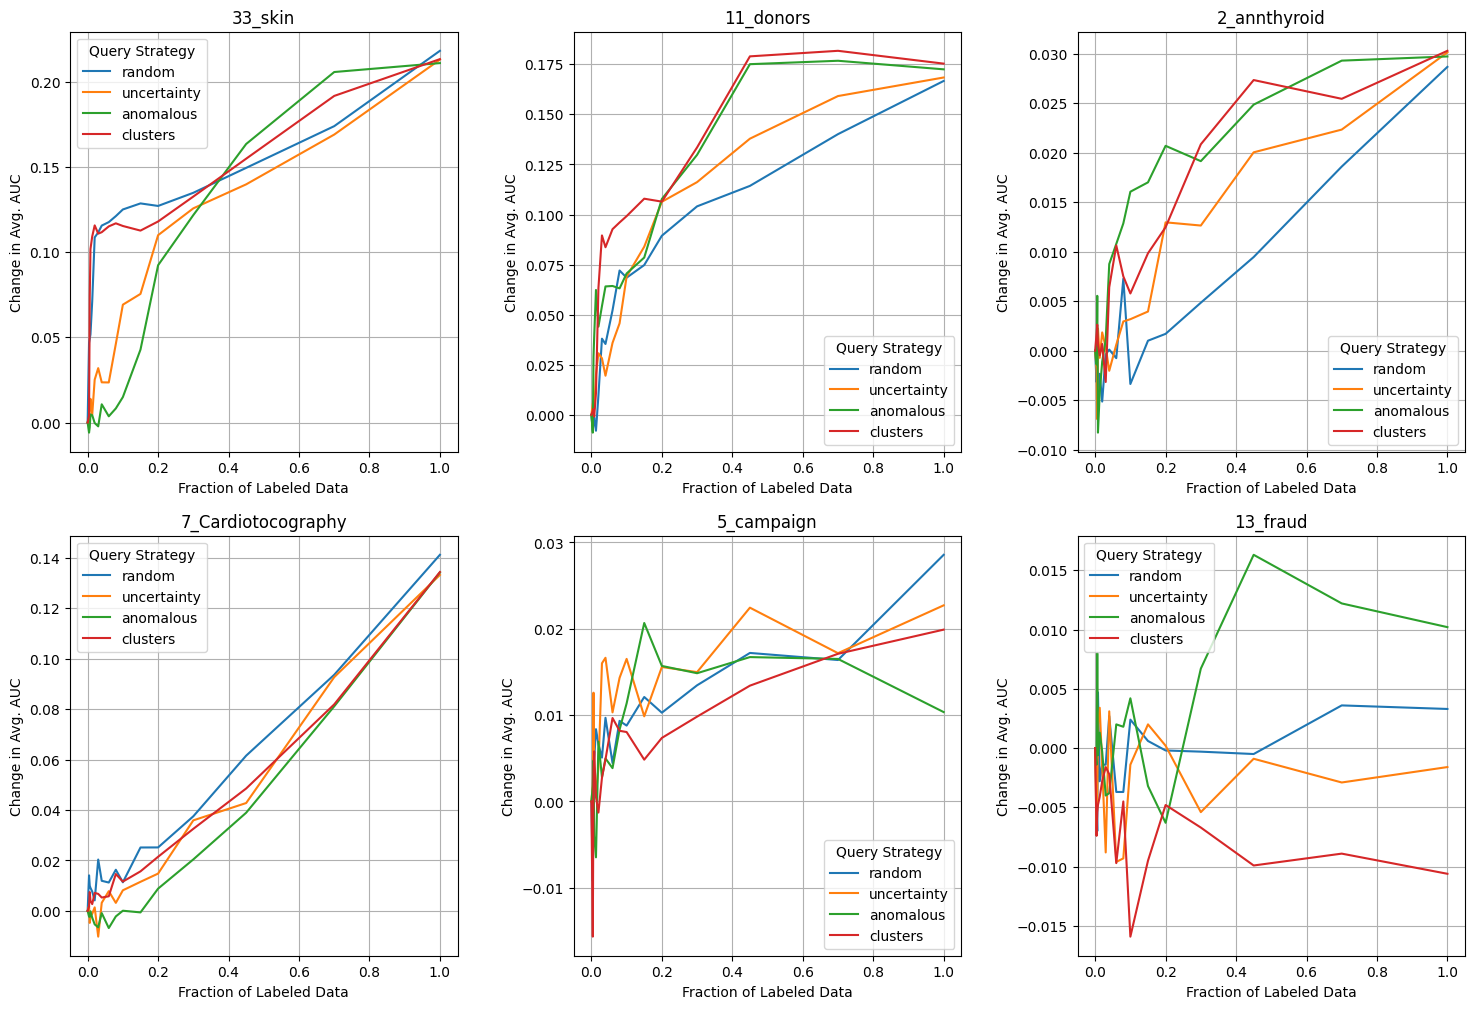

In [ ]:
plot_roc_auc_change_by_query_strategy(results)

# <a id='toc4_'></a>[References](#toc0_)